In [1]:
# Import necessary packages

import os
import glob
import sys
from concurrent.futures import ThreadPoolExecutor, ProcessPoolExecutor
import logging

import tifffile as tiff
import numpy as np
import matplotlib.pyplot as plt
import plotnine as p9
import pandas as pd
from skimage import feature, io
from scipy.stats import norm
from scipy.ndimage import label, find_objects

# Make path for scripts relative to the working directory
sys.path.insert(0, '../src')  # Adjust the path as needed

# Setup basic logging
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')

In [3]:
# Define path names and load some basic functions for reading in files

# Define the location of the file to read
parent_directory = "/Users/nestor/Dropbox/Work/DIMMERs/microscope-data" # modify if needed
repo_directory = "/Users/nestor/Documents/NYU-ISG/python_image-analysis" # analysis code directory
experiment_list = ["08052024_pDIMMERs", "08122024_pDIMMERs",
                  "10032024_pDIMMERs", "10072024_pDIMMERs"] # this will be changed for each experiment

# This dictionary defines the folder inside of "experiment" that contains masks
file_folders = {
    "mask_n": "segmentation-masks/nuclei_masks/"
}

# Load the function img_loadr() 
from load_files import img_loadr

def extract_base_name(filename):
    """
    Extract the base name from the file name without removing important parts of the name,
    such as the date and experiment information, while stripping the channel prefixes from masks.
    """
    name = os.path.basename(filename)

    # Only remove 'C1-', 'C2-', etc., from mask files
    if name.startswith(("C1-", "C2-", "C3-", "C4-", "C5-")):
        name = name[3:]  # Remove the first 3 characters (e.g., 'C1-', 'C2-', etc)
    
    # Remove the "_cp_masks" suffix for masks or ".ome" from image files if present
    name = name.replace("_cp_masks", "").replace(".ome", "")
    
    # Remove the file extension
    base_name = os.path.splitext(name)[0]
    
    return base_name

In [5]:
# CHUNK 1 # 
# Load segmentation masks for images in one experiment

# Create a dictionary to store data across multiple experiments
all_experiments_data = {}

# Iterate through each experiment in experiment_list
for experiment in experiment_list:
    # Initialize data structures for the current experiment
    exp_data = {
        "all_images": {"mask_n": []},
        "file_names": {"mask_n": []},
        "base_names": {"mask_n": []},
        "errors": []
    }

    # Read in the experimental groups reference file for each experiment
    exp_groups = pd.read_csv(os.path.join(parent_directory, experiment, "experimental-groups.csv"))

    # Process each file type using img_loadr
    with ThreadPoolExecutor(max_workers=4) as executor:
        for f in file_folders:
            file_path = os.path.join(parent_directory, experiment, file_folders[f])
            files = glob.glob(os.path.join(file_path, "*.tif"))
            results = executor.map(img_loadr, files)

            for result in results:
                image, filename = result
                if image is not None:
                    exp_data["all_images"][f].append(image)
                    exp_data["file_names"][f].append(filename)
                    exp_data["base_names"][f].append(extract_base_name(filename))
                else:
                    exp_data["errors"].append(f"Error loading {filename}")

    # Log the completion of processing for this experiment
    if exp_data["errors"]:
        logging.error(f"{experiment}: Completed with errors in {len(exp_data['errors'])} files.")
    else:
        logging.info(f"{experiment}: All images and masks processed successfully without errors.")
    
    # Store the experiment's data under its name
    all_experiments_data[experiment] = exp_data

# Optional: Summary of processed files for all experiments
for experiment, data in all_experiments_data.items():
    logging.info(f"{experiment}: Processed {len(data['file_names']['mask_n'])} nuclei masks.")

2024-11-05 19:33:45,952 - INFO - 08052024_pDIMMERs: All images and masks processed successfully without errors.
2024-11-05 19:33:46,242 - INFO - 08122024_pDIMMERs: All images and masks processed successfully without errors.
2024-11-05 19:33:46,688 - INFO - 10032024_pDIMMERs: All images and masks processed successfully without errors.
2024-11-05 19:33:46,916 - INFO - 10072024_pDIMMERs: All images and masks processed successfully without errors.
2024-11-05 19:33:46,917 - INFO - 08052024_pDIMMERs: Processed 67 nuclei masks.
2024-11-05 19:33:46,917 - INFO - 08122024_pDIMMERs: Processed 113 nuclei masks.
2024-11-05 19:33:46,917 - INFO - 10032024_pDIMMERs: Processed 138 nuclei masks.
2024-11-05 19:33:46,918 - INFO - 10072024_pDIMMERs: Processed 84 nuclei masks.


In [7]:
# CHUNK 2 #
# Load spot files for each image into a dictionary

# Initialize dictionary to store spot data across multiple experiments
all_experiments_spots = {}

# Loop through each experiment in experiment_list
for experiment in experiment_list:
    # Initialize data structures for the current experiment
    exp_spots = {
        "spot_files": {"spots": []},
        "spot_file_names": {"spots": []},
        "spot_base_names": {"spots": []},
        "spot_channels": [],
        "spot_errors": []
    }

    # Define the folder containing the spot files for the current experiment
    spots_folder = "spotiflow_results/"
    spots_path = os.path.join(parent_directory, experiment, spots_folder)

    # List all CSV files in the directory
    csv_files = glob.glob(os.path.join(spots_path, "*.csv"))

    # Read each CSV file and store the data and filename in the experiment's spot dictionary
    for file in csv_files:
        try:
            spots = pd.read_csv(file)  # Assumes a simple CSV structure; modify if necessary
            file_name = os.path.basename(file)

            # Extract the channel from the file name (e.g., C1, C2, etc.)
            # Assumes file name starts with C followed by a number (such as "C1-", "C2-", etc)
            channel = int(file_name.split('-')[0][1])  # Get the number after 'C'

            exp_spots["spot_files"]['spots'].append(spots)
            exp_spots["spot_file_names"]['spots'].append(file_name)  # Save the filename
            exp_spots["spot_base_names"]['spots'].append(extract_base_name(file_name))  # Store the base name
            exp_spots["spot_channels"].append(channel)  # Save the channel
            
        except Exception as e:
            exp_spots["spot_errors"].append(file)
            logging.error(f"Error reading {file} in {experiment}: {str(e)}")

    # Log completion for this experiment
    if exp_spots["spot_errors"]:
        logging.error(f"{experiment}: Completed with errors in {len(exp_spots['spot_errors'])} files.")
    else:
        logging.info(f"{experiment}: All spot files loaded successfully.")

    # Store the experiment's spot data in the main dictionary
    all_experiments_spots[experiment] = exp_spots

# Optional: Summary of processed spot files for all experiments
for experiment, data in all_experiments_spots.items():
    logging.info(f"{experiment}: Processed {len(data['spot_file_names']['spots'])} spot files.")


2024-11-05 19:33:49,311 - INFO - 08052024_pDIMMERs: All spot files loaded successfully.
2024-11-05 19:33:49,366 - INFO - 08122024_pDIMMERs: All spot files loaded successfully.
2024-11-05 19:33:49,428 - INFO - 10032024_pDIMMERs: All spot files loaded successfully.
2024-11-05 19:33:49,461 - INFO - 10072024_pDIMMERs: All spot files loaded successfully.
2024-11-05 19:33:49,462 - INFO - 08052024_pDIMMERs: Processed 67 spot files.
2024-11-05 19:33:49,462 - INFO - 08122024_pDIMMERs: Processed 113 spot files.
2024-11-05 19:33:49,462 - INFO - 10032024_pDIMMERs: Processed 138 spot files.
2024-11-05 19:33:49,462 - INFO - 10072024_pDIMMERs: Processed 84 spot files.


In [9]:
# CHUNK 3 #
# Match spot files to nuclear mask files using the base_names common to all files

# Initialize a dictionary to store matched indices for each experiment
all_matched_indices_with_spots = {}

# Loop through each experiment
for experiment in experiment_list:
    # Retrieve base names for nuclear masks and spot files in the current experiment
    mask_base_names = all_experiments_data[experiment]["base_names"]["mask_n"]
    spot_base_names = all_experiments_spots[experiment]["spot_base_names"]["spots"]

    # Convert list of spot base names to a dictionary for faster lookup
    spot_name_to_index = {base_name: idx for idx, base_name in enumerate(spot_base_names)}

    # Initialize lists and counters for matched indices and missing spots
    matched_indices_with_spots = []
    missing_spots = 0

    # Match each nuclear mask with its corresponding spot file
    for mask_index, mask_base_name in enumerate(mask_base_names):
        spot_index = spot_name_to_index.get(mask_base_name)  # Use base names to match

        if spot_index is not None:
            matched_indices_with_spots.append((mask_index, spot_index))
        else:
            missing_spots += 1
            logging.warning(f"No matching spot file found for mask: {all_experiments_data[experiment]['file_names']['mask_n'][mask_index]} in {experiment}")

    # Store matched indices for the current experiment
    all_matched_indices_with_spots[experiment] = matched_indices_with_spots

    # Log the results of the matching for the current experiment
    logging.info(f"{experiment}: Matched {len(matched_indices_with_spots)} nuclear masks with spot files. Missing spot files for {missing_spots} masks.")

# Optional: Summary of matched indices for all experiments
for experiment, matched_indices in all_matched_indices_with_spots.items():
    logging.info(f"{experiment}: Total matched nuclear masks with spots - {len(matched_indices)}")


2024-11-05 19:33:52,580 - INFO - 08052024_pDIMMERs: Matched 67 nuclear masks with spot files. Missing spot files for 0 masks.
2024-11-05 19:33:52,584 - INFO - 08122024_pDIMMERs: Matched 113 nuclear masks with spot files. Missing spot files for 0 masks.
2024-11-05 19:33:52,585 - INFO - 10032024_pDIMMERs: Matched 138 nuclear masks with spot files. Missing spot files for 0 masks.
2024-11-05 19:33:52,586 - INFO - 10072024_pDIMMERs: Matched 84 nuclear masks with spot files. Missing spot files for 0 masks.
2024-11-05 19:33:52,587 - INFO - 08052024_pDIMMERs: Total matched nuclear masks with spots - 67
2024-11-05 19:33:52,588 - INFO - 08122024_pDIMMERs: Total matched nuclear masks with spots - 113
2024-11-05 19:33:52,589 - INFO - 10032024_pDIMMERs: Total matched nuclear masks with spots - 138
2024-11-05 19:33:52,590 - INFO - 10072024_pDIMMERs: Total matched nuclear masks with spots - 84


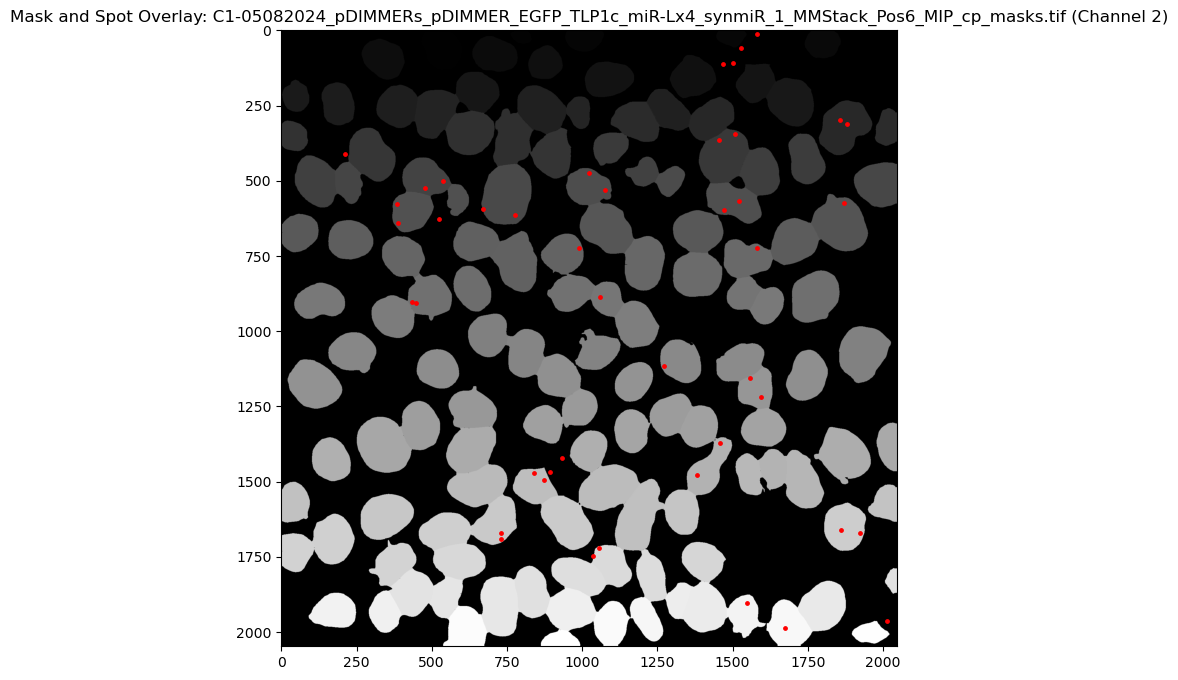

In [11]:
# Overlay a mask and its spot coordinates for visual confirmation that
# a) match was correct
# b) XY axes align on both images

# Pick an experiment from experiment_list, an image and a channel to overlay, using indices
e = 0 # index for experiment (from 0 to length(experiment_list - 1))
experiment = experiment_list[e]
i = 1 # image index (1 - (n images -1))
c = 2 # channel to overlay (1-index, from C1-, C2, C3-)

# Retrieve the matched indices for the selected experiment
matched_indices = all_matched_indices_with_spots[experiment]
mask_index, spot_index = matched_indices[i]

# Access mask and spot data for the chosen experiment and indices
mask = all_experiments_data[experiment]['all_images']['mask_n'][mask_index]
mask_base_name = all_experiments_data[experiment]['base_names']['mask_n'][mask_index]

# Find the corresponding spot file for the chosen channel
spot_found = False
for j, spot_base_name in enumerate(all_experiments_spots[experiment]['spot_base_names']['spots']):
    if spot_base_name == mask_base_name and all_experiments_spots[experiment]['spot_channels'][j] == c:
        spots = all_experiments_spots[experiment]['spot_files']['spots'][j]
        spot_found = True
        break

# Proceed with plotting if the corresponding spot file for the chosen channel is found
if spot_found:
    # The spot files have 'x' and 'y' as labels for columns containing coordinates
    x_coords = spots['x']
    y_coords = spots['y']

    # Plot the mask
    plt.figure(figsize=(8, 8))
    plt.imshow(mask, cmap='gray')
    plt.scatter(x_coords, y_coords, color='red', s=6)  # Overlay spots in red
    plt.title(f"Mask and Spot Overlay: {all_experiments_data[experiment]['file_names']['mask_n'][mask_index]} (Channel {c})")
    plt.show()
else:
    print(f"No spot data found for channel {c} at index {i} in experiment {experiment}.")

In [13]:
# CHUNK 4 (updated using base_names) #
# Assign each spot to a nuclear mask ROI based on their coordinates

# Generate a dictionary to hold the number of spots per ROI for all experiments
spot_counts_per_roi = {}

# Loop through each experiment
for experiment in experiment_list:
    # Retrieve matched indices for the current experiment
    matched_indices = all_matched_indices_with_spots[experiment]
    
    # Retrieve data for masks and spots for the current experiment
    mask_base_names = all_experiments_data[experiment]['base_names']['mask_n']
    masks = all_experiments_data[experiment]['all_images']['mask_n']
    spot_files = all_experiments_spots[experiment]['spot_files']['spots']
    spot_channels = all_experiments_spots[experiment]['spot_channels']

    # Iterate through each matched mask and spot file
    for mask_base_name, (mask_index, spot_index) in zip(mask_base_names, matched_indices):
        my_mask = masks[mask_index]
        spot_coords = spot_files[spot_index]
        channel = spot_channels[spot_index]  # Get the channel for the current spot file

        # Get all unique ROI values in the mask (excluding background 0) and initialize them with zero spot count
        unique_rois = np.unique(my_mask)
        for roi_value in unique_rois:
            if roi_value != 0:  # Skip background
                key = (experiment, mask_base_name, roi_value, channel)  # Key includes experiment, mask base name, ROI, and channel
                if key not in spot_counts_per_roi:
                    spot_counts_per_roi[key] = 0  # Initialize ROI with zero spots

        # Round and convert spot coordinates to integers for indexing
        x_coords = np.round(spot_coords['x']).values.astype(int)
        y_coords = np.round(spot_coords['y']).values.astype(int)

        # Assign each spot to an ROI in the mask based on coordinates
        for x, y in zip(x_coords, y_coords):
            # Ensure the spot's coordinates are within the mask's bounds
            if 0 <= y < my_mask.shape[0] and 0 <= x < my_mask.shape[1]:
                roi_value = my_mask[y, x]  # The value in the mask at the spot's location
                if roi_value != 0:  # Skip background
                    key = (experiment, mask_base_name, roi_value, channel)  # Key includes experiment and channel
                    spot_counts_per_roi[key] += 1  # Increment the spot count for the ROI

# The result is a spot_counts_per_roi dictionary with keys that include experiment, mask base name, ROI, and channel

In [45]:
# Convert the dictionary to a Pandas data frame

# Initialize a list to store the data for the DataFrame
spot_data = []

# Iterate through the spot_counts_per_roi dictionary
for (experiment, mask_base_name, roi_value, channel), spot_count in spot_counts_per_roi.items():
    spot_data.append({
        'experiment': experiment,     # Experiment name
        'base_name': mask_base_name,  # Base name of the mask/spot file
        'ROI': roi_value,             # ROI value
        'channel': channel,           # Channel number
        'spot_count': spot_count      # Number of spots in this ROI for the specific channel
    })

# Create a DataFrame from the collected data
spot_df = pd.DataFrame(spot_data)

# Display a sample of the data frame
print(spot_df.head(10))

          experiment                                          base_name  ROI  \
0  08052024_pDIMMERs  05082024_pDIMMERs_pPGK_NT-EGFP_TLP1c_1_MMStack...    1   
1  08052024_pDIMMERs  05082024_pDIMMERs_pPGK_NT-EGFP_TLP1c_1_MMStack...    2   
2  08052024_pDIMMERs  05082024_pDIMMERs_pPGK_NT-EGFP_TLP1c_1_MMStack...    3   
3  08052024_pDIMMERs  05082024_pDIMMERs_pPGK_NT-EGFP_TLP1c_1_MMStack...    4   
4  08052024_pDIMMERs  05082024_pDIMMERs_pPGK_NT-EGFP_TLP1c_1_MMStack...    5   
5  08052024_pDIMMERs  05082024_pDIMMERs_pPGK_NT-EGFP_TLP1c_1_MMStack...    6   
6  08052024_pDIMMERs  05082024_pDIMMERs_pPGK_NT-EGFP_TLP1c_1_MMStack...    7   
7  08052024_pDIMMERs  05082024_pDIMMERs_pPGK_NT-EGFP_TLP1c_1_MMStack...    8   
8  08052024_pDIMMERs  05082024_pDIMMERs_pPGK_NT-EGFP_TLP1c_1_MMStack...    9   
9  08052024_pDIMMERs  05082024_pDIMMERs_pPGK_NT-EGFP_TLP1c_1_MMStack...   10   

   channel  spot_count  
0        2           0  
1        2           0  
2        2           0  
3        2         

In [17]:
# Read in the cell classification generated by me with img-explorer.ipynb
cell_clx = pd.read_csv(os.path.join(repo_directory, "pDIMMERs_cell-class.csv"))
cell_clx.rename(columns = {'filename': 'base_name', 
                           'ROI_index': 'ROI'}, inplace = True)

In [21]:
# Read in the cell classification generated by Tasnim
taz_data = pd.read_csv(os.path.join(repo_directory, "pDIMMERs_Tas.csv"))
taz_data.rename(columns = {'filename': 'base_name', 
                           'ROI_index': 'ROI'}, inplace = True)

# Select only Channel 1 (EGFP) and generate log10(EGFP)
taz_data = taz_data[taz_data['channel'] == 1]
taz_data['ch1_log10_median'] = np.log10(taz_data['median'] + 1)

# Flip the transfected classification (for her N is non-negative (positive) cell and Y is negative cell)
taz_data['tx_status_taz'] = np.where(taz_data['within_threshold'] == "Y", "N", "Y")

In [267]:
# Merge spot_df with my own classification
spot_df = pd.merge(spot_df, 
                   cell_clx[['plasmid', 'experiment', 'base_name', 'ROI', 'tx_status_thr', 'ch1_log10_median']], 
                   on = ['base_name', 'experiment', 'ROI'], how = 'inner')

In [47]:
# Or merge with Tasnim's classification
spot_df = pd.merge(spot_df, 
                   taz_data[['plasmid', 'experiment', 'base_name', 'ROI', 'tx_status_taz', 'ch1_log10_median']], 
                   on = ['base_name', 'experiment', 'ROI'], how = 'inner')

In [49]:
#print(spot_df.head(10))
print(spot_df['base_name'].count())

42664


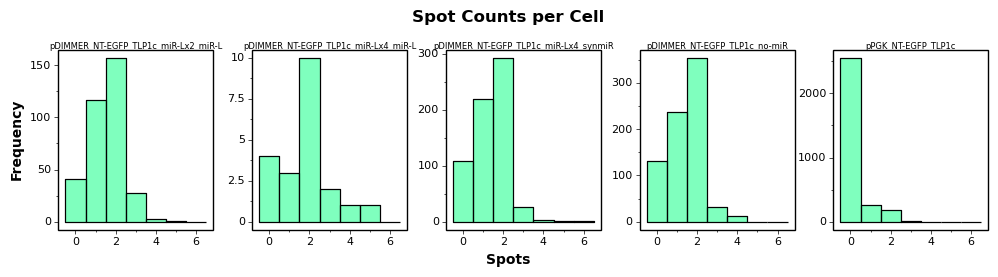

In [67]:
# Plot the number of spots found for all ROIs in all images

# Define a dictionary of channel colors
channel_colors = {1: 'blue', 2: 'springgreen', 3: 'magenta'}

# Define some list of values to filter by
my_plasmids = ['pDIMMER_NT-EGFP_TLP1c_no-miR', 'pDIMMER_NT-EGFP_TLP1c_miR-Lx4_synmiR',
               'pDIMMER_NT-EGFP_TLP1c_miR-Lx4_miR-L', 'pDIMMER_NT-EGFP_TLP1c_miR-Lx2_miR-L', 
               'pPGK_NT-EGFP_TLP1c', 'pDIMMER_NT-EGFP_TLP1c_mirLx4_mRuby_miR-L',
               'pDIMMER_NT-EGFP_TLP1c_mirLx4_mRuby_synmiR', 'none']
aug_experiments = ['08052024_pDIMMERs', '08122024_pDIMMERs']
oct_experiments = ['10032024_pDIMMERs', '10072024_pDIMMERs']

# Reorder channels so that Channel 2 (GFP) is plotted over Channel 3 (FISH)
spot_df['channel'] = pd.Categorical(spot_df['channel'], categories=[3, 2], ordered=True)

my_spots = spot_df[(spot_df['spot_count'] <= 10) & 
(spot_df['experiment'].isin(aug_experiments)) & 
(spot_df['tx_status_taz'] == 'Y') & 
(spot_df['plasmid'] != "none")]

# Determine the largest number of spots to set the X axis of the plot
#max_spot_count = spot_df['spot_count'].max()
max_spot_count = 10

# Define the plot with overlaid histograms for each channel
spot_histogram = (
    p9.ggplot(my_spots, 
              p9.aes(x = 'spot_count', 
                     fill = 'factor(channel)')) +  # Set the data and x-axis aesthetic
    p9.geom_histogram(binwidth = 1, color = 'black', 
                      alpha = 0.5, position = 'identity') +  # Overlaid histograms
    p9.labs(title = 'Spot Counts per Cell', 
            x = 'Spots', y = 'Frequency', fill = 'Channel') +  # Add labels
    #p9.facet_grid('tx_status_taz ~ plasmid', scales = "free_y") +
    p9.facet_wrap(' ~ plasmid', scales = 'free_y', nrow = 1) +
    p9.scale_fill_manual(values = channel_colors) +  # Apply the custom channel colors
    p9.scale_x_continuous(breaks = range(0, max_spot_count + 1, 2)) + 
    p9.theme_bw() +  # Apply theme
    p9.theme(figure_size = (12, 6),
             subplots_adjust = {'wspace': 0.25},  # Adjust space between plots
             aspect_ratio = 1,
             panel_grid = p9.element_blank(), 
             panel_border = p9.element_rect(color='black', linewidth=1), 
             axis_ticks = p9.element_line(color='black', linewidth=0.5), 
             plot_title = p9.element_text(size=12, color='black', face='bold'),
             axis_text = p9.element_text(size=8, color='black'), 
             axis_title = p9.element_text(size=10, color='black', face='bold'), 
             legend_text = p9.element_text(size=8, color='black'), 
             legend_title = p9.element_text(size=10, color='black', face='bold'),
             legend_position = 'none',
             strip_background = p9.element_blank(), 
             strip_text = p9.element_text(size=6, color='black'))
)

# Display the plot
print(spot_histogram)

In [53]:
print(my_spots.groupby(['base_name', 'ROI']).ngroups)

4803


In [55]:
# Calculate the fraction of positive cells that have 1-4 spots vs no spots

# Filter cells with up to 4 spots only (the majority anyway)
spot_count_df = spot_df[spot_df['spot_count'] <= 4]

# Group by experiment, plasmid, base_name, and transfection status (tx_status) 
# then calculate counts for ROIs with and without spots
spot_summary = spot_count_df.groupby(['experiment', 'plasmid', 'base_name', 'tx_status_taz']).apply(lambda group: pd.Series({
    'total_rois': group['ROI'].nunique(),             # Total unique ROIs per group
    'rois_with_spots': group[group['spot_count'] > 0]['ROI'].nunique(),  # ROIs with spots
    'rois_without_spots': group[group['spot_count'] == 0]['ROI'].nunique()  # ROIs without spots
})).reset_index()

# Step 3: Calculate percentages
spot_summary['pc_rois_with_spots'] = (spot_summary['rois_with_spots'] / spot_summary['total_rois']) * 100
spot_summary['pc_rois_wo_spots'] = (spot_summary['rois_without_spots'] / spot_summary['total_rois']) * 100

#print(spot_summary.head())

In [57]:
# Incorporate some metadata into spot_summary
plasmid_ref = pd.read_csv(os.path.join(repo_directory, 'reference/', 'plasmid_ref_pDIMMERs.csv'))
spot_summary = pd.merge(spot_summary, 
                        plasmid_ref,
                        on = "plasmid", how = 'left')

In [59]:
# Reorder elements of spot_summary for plotting
plasmid_order = ['pCMV_NT-EGFP_TLP1c', 'pCMV_NT-EGFP_TLP1c_miR-Lx4_miR-L',
                 'pEC_NT-EGFP_TLP1c', 'pEC_NT-EGFP_TLP1c_miR-Lx4_miR-L', 
                 'pPGK_NT-EGFP_TLP1c', 'pPGK_NT-EGFP_TLP1c_miR-Lx4_miR-L', 
                 'pDIMMER_NT-EGFP_TLP1c_no-miR', 'pDIMMER_NT-EGFP_TLP1c_miR-Lx4_synmiR', 
                 'pDIMMER_NT-EGFP_TLP1c_miR-Lx2_miR-L','pDIMMER_NT-EGFP_TLP1c_miR-Lx4_miR-L', 
                 'pDIMMER_NT-EGFP_TLP1c_mirLx4_mRuby_synmiR', 'pDIMMER_NT-EGFP_TLP1c_mirLx4_mRuby_miR-L', 'none']
miRNA_order = ['no_miR', 'synmiR', 'miR-L']
promoter_order = ['pCMV', 'pCMV-EF1a', 'pPGK', 'pECM']

spot_summary['plasmid'] = pd.Categorical(spot_summary['plasmid'], categories = plasmid_order, ordered = True)
spot_summary['miRNA'] = pd.Categorical(spot_summary['miRNA'], categories = miRNA_order, ordered = True)
spot_summary['promoter'] = pd.Categorical(spot_summary['promoter'], categories = promoter_order, ordered = True)

/Users/nestor/anaconda3/envs/python-img/lib/python3.11/site-packages/plotnine/layer.py:411: PlotnineWarning: geom_jitter : Removed 21 rows containing missing values.


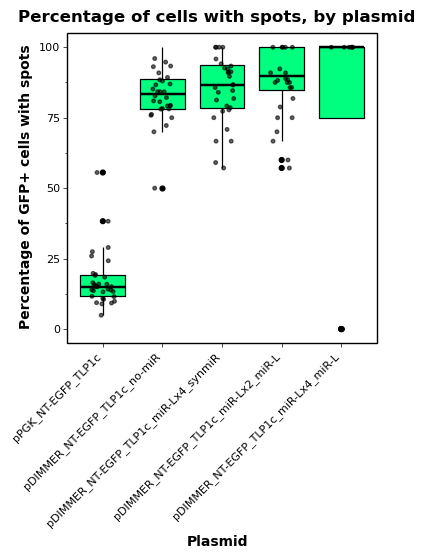

/Users/nestor/anaconda3/envs/python-img/lib/python3.11/site-packages/plotnine/layer.py:411: PlotnineWarning: geom_jitter : Removed 6 rows containing missing values.


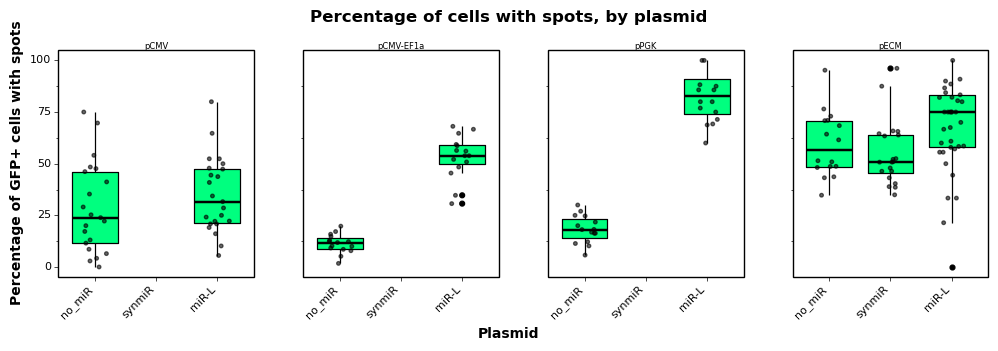

In [61]:
# Plot the results of the calculations above:

my_spots = spot_summary[(spot_summary['tx_status_taz'] == "Y") & 
(spot_summary['experiment'].isin(aug_experiments)) &
(spot_summary['plasmid'] != 'none')]


# Create a plot for experiments from August
exp1_boxplot = (
    p9.ggplot(my_spots, 
              p9.aes(x = 'plasmid', 
                     y = 'pc_rois_with_spots')) +
    p9.geom_boxplot(outlier_shape = None, 
                    color = "black", fill = "springgreen") +  # Box plot without outliers to avoid overlap with scatter points
    p9.geom_jitter(width = 0.2, size = 1, color = "black", alpha = 0.6) +  # Scatter plot with jitter for visibility
    p9.labs(title = "Percentage of cells with spots, by plasmid",
            x = "Plasmid", 
            y = "Percentage of GFP+ cells with spots") + 
    p9.scale_y_continuous(limits=(0, 100)) + 
    #p9.facet_grid('promoter ~ ') +
    p9.theme_bw() +  # Apply theme
    p9.theme(figure_size = (4, 4),
             subplots_adjust = {'wspace': 0.25},  # Adjust space between plots
             aspect_ratio = 1,
             panel_grid = p9.element_blank(), 
             panel_border = p9.element_rect(color='black', linewidth=1), 
             axis_ticks = p9.element_line(color='black', linewidth=0.5), 
             plot_title = p9.element_text(size=12, color='black', face='bold'),
             axis_text_x = p9.element_text(size=8, color='black', angle = 45, hjust = 1), 
             axis_text_y = p9.element_text(size=8, color='black'), 
             axis_title = p9.element_text(size=10, color='black', face='bold'), 
             legend_text = p9.element_text(size=8, color='black'), 
             legend_title = p9.element_text(size=10, color='black', face='bold'),
             legend_position = 'none',
             strip_background = p9.element_blank(), 
             strip_text = p9.element_text(size=6, color='black'))
)

# Create a plot for experiments switching promoters

my_spots = spot_summary[(spot_summary['tx_status_taz'] == "Y") & 
(spot_summary['experiment'].isin(oct_experiments)) &
(spot_summary['plasmid'] != 'none')]

exp2_boxplot = (
    p9.ggplot(my_spots, 
              p9.aes(x = 'miRNA', 
                     y = 'pc_rois_with_spots')) +
    p9.geom_boxplot(outlier_shape = None, 
                    color = "black", fill = "springgreen") +  # Box plot without outliers to avoid overlap with scatter points
    p9.geom_jitter(width = 0.2, size = 1, color = "black", alpha = 0.6) +  # Scatter plot with jitter for visibility
    p9.labs(title = "Percentage of cells with spots, by plasmid",
            x = "Plasmid", 
            y = "Percentage of GFP+ cells with spots") + 
    p9.scale_y_continuous(limits=(0, 100)) + 
    p9.facet_grid(' ~ promoter') +
    p9.theme_bw() +  # Apply theme
    p9.theme(figure_size = (12, 6),
             subplots_adjust = {'wspace': 0.25},  # Adjust space between plots
             aspect_ratio = 1,
             panel_grid = p9.element_blank(), 
             panel_border = p9.element_rect(color='black', linewidth=1), 
             axis_ticks = p9.element_line(color='black', linewidth=0.5), 
             plot_title = p9.element_text(size=12, color='black', face='bold'),
             axis_text_x = p9.element_text(size=8, color='black', angle = 45, hjust = 1), 
             axis_text_y = p9.element_text(size=8, color='black'), 
             axis_title = p9.element_text(size=10, color='black', face='bold'), 
             legend_text = p9.element_text(size=8, color='black'), 
             legend_title = p9.element_text(size=10, color='black', face='bold'),
             legend_position = 'none',
             strip_background = p9.element_blank(), 
             strip_text = p9.element_text(size=6, color='black'))
)

# Display the plot
print(exp1_boxplot)
print(exp2_boxplot)

In [69]:
# Save the plot to disk as a PDF file
plot_dir = os.path.join(repo_directory, "plots")
os.makedirs(plot_dir, exist_ok = True)
plot1_filename = 'pc_with_spots_Aug.pdf'  # Replace with your desired file name
plot2_filename = 'pc_with_spots_promoters.pdf' # Replace with your desired file name
exp1_boxplot.save(f"{plot_dir}/{plot1_filename}", format = 'pdf', dpi = 300) 
exp2_boxplot.save(f"{plot_dir}/{plot2_filename}", format = 'pdf', dpi = 300) 

/Users/nestor/anaconda3/envs/python-img/lib/python3.11/site-packages/plotnine/ggplot.py:718: PlotnineWarning: Saving 4 x 4 in image.
/Users/nestor/anaconda3/envs/python-img/lib/python3.11/site-packages/plotnine/ggplot.py:719: PlotnineWarning: Filename: /Users/nestor/Documents/NYU-ISG/python_image-analysis/plots/pc_with_spots_Aug.pdf
/Users/nestor/anaconda3/envs/python-img/lib/python3.11/site-packages/plotnine/layer.py:411: PlotnineWarning: geom_jitter : Removed 14 rows containing missing values.
/Users/nestor/anaconda3/envs/python-img/lib/python3.11/site-packages/plotnine/ggplot.py:718: PlotnineWarning: Saving 12 x 6 in image.
/Users/nestor/anaconda3/envs/python-img/lib/python3.11/site-packages/plotnine/ggplot.py:719: PlotnineWarning: Filename: /Users/nestor/Documents/NYU-ISG/python_image-analysis/plots/pc_with_spots_promoters.pdf
/Users/nestor/anaconda3/envs/python-img/lib/python3.11/site-packages/plotnine/layer.py:411: PlotnineWarning: geom_jitter : Removed 6 rows containing missing 